In [1]:
from experiments.dj.posterior_tables import SBVGPConfig
from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import SBVGPResult, SIResult, FlowPriorResult
from task_transfer.utils.insilico_stimuli import generate_gabors 

import torch
import matplotlib.pyplot as plt
import seaborn as sns


torch.manual_seed(42)

[2024-06-20 16:13:05,009][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-06-20 16:13:05,108][INFO]: Connected sshrinivasan@134.76.19.44:3306
/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [2]:
best_prior = FlowPriorResult.fetch(
    download_path="/tmp", order_by="val_ll_mean DESC", limit=1, as_dict=True
)[0]

In [3]:
best_si = SIResult.fetch(
    download_path="/tmp", order_by="val_ll_mean DESC", limit=1, as_dict=True
)[0]
best_sbv = SBVGPResult.fetch(
    download_path="/tmp", order_by="val_ll_mean DESC", limit=1, as_dict=True
)[0]

In [4]:
best_prior

{'fp_id': '89c1053a65023b042dc63f7f852bb5b0',
 'trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'dl_id': '260a5ea8175f75eaef132f42873ad14a',
 'train_ll_mean': -51.37348556518555,
 'train_ll_sem': 1.190269112586975,
 'val_ll_mean': -51.278499603271484,
 'val_ll_sem': 2.2305781841278076,
 'test_ll_mean': -51.278499603271484,
 'test_ll_sem': 2.2305781841278076,
 'tracker_output': '/tmp/89c1053a65023b042dc63f7f852bb5b0_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_tracker_output.pkl',
 'eval_output': '/tmp/89c1053a65023b042dc63f7f852bb5b0_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_eval_output.pkl',
 'model': '/tmp/89c1053a65023b042dc63f7f852bb5b0_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_model.pt'}

In [5]:
best_si_model = torch.load(best_si["model"], map_location="cpu")
best_sbv_model = torch.load(best_sbv["model"], map_location="cpu")

In [6]:
train_logls = [best_si["train_ll_mean"], best_sbv["train_ll_mean"], best_prior["train_ll_mean"]]
val_logls = [best_si["val_ll_mean"], best_sbv["val_ll_mean"], best_prior["val_ll_mean"]]
test_logls = [best_si["test_ll_mean"], best_sbv["test_ll_mean"], best_prior["test_ll_mean"]]

train_logls_sems = [best_si["train_ll_sem"], best_sbv["train_ll_sem"], best_prior["train_ll_sem"]]
val_logls_sems = [best_si["val_ll_sem"], best_sbv["val_ll_sem"], best_prior["val_ll_sem"]]
test_logls_sems = [best_si["test_ll_sem"], best_sbv["test_ll_sem"], best_prior["test_ll_sem"]]

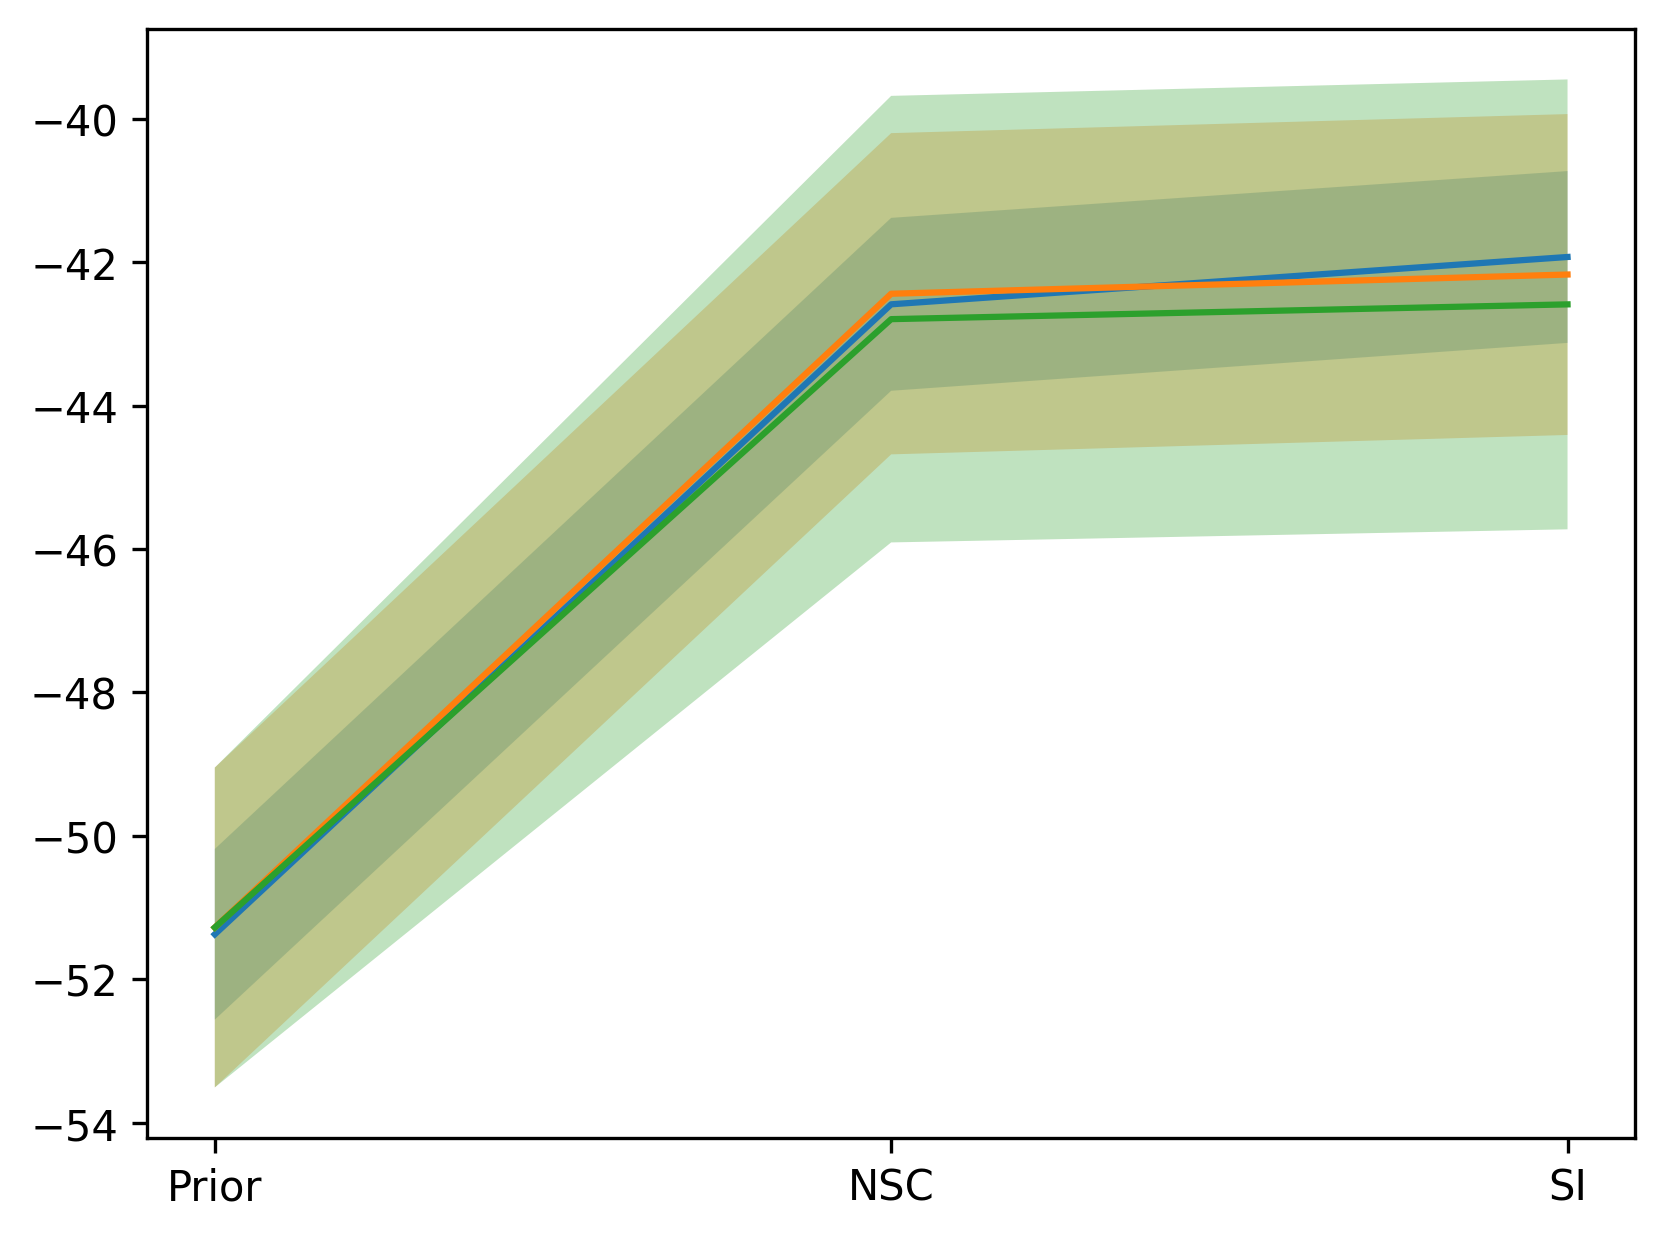

In [7]:
fig, ax = plt.subplots(dpi=300)
x = ["Prior", "NSC", "SI"]
ax.plot(x, train_logls[::-1])
ax.fill_between(x, [train_logls[i] - train_logls_sems[i] for i in range(3)][::-1], [train_logls[i] + train_logls_sems[i] for i in range(3)][::-1], alpha=0.3)
ax.plot(x, val_logls[::-1])
ax.fill_between(x, [val_logls[i] - val_logls_sems[i] for i in range(3)][::-1], [val_logls[i] + val_logls_sems[i] for i in range(3)][::-1], alpha=0.3)
ax.plot(x, test_logls[::-1])
ax.fill_between(x, [test_logls[i] - test_logls_sems[i] for i in range(3)][::-1], [test_logls[i] + test_logls_sems[i] for i in range(3)][::-1], alpha=0.3)

# Inspecting the predictive models

## Creating stimuli

In [8]:
orientations = torch.linspace(0, torch.pi, steps=45 + 1)[:-1]
obs_h, obs_w = 12, 12
gabor_params = dict(
    {
        "canvas_size": [obs_h, obs_w],
        "sizes": [10],
        "spatial_frequencies": [1 / 3],
        "contrasts": [1.0],
        "grey_levels": [0.0],
        "eccentricities": [0.0],
        "locations": [[6, 6]],
        "phases": [torch.pi / 2],
        "relative_sf": False,
    },
)
stimuli = torch.Tensor(
    generate_gabors(orientations=orientations.tolist(), gabor_params=gabor_params)
)

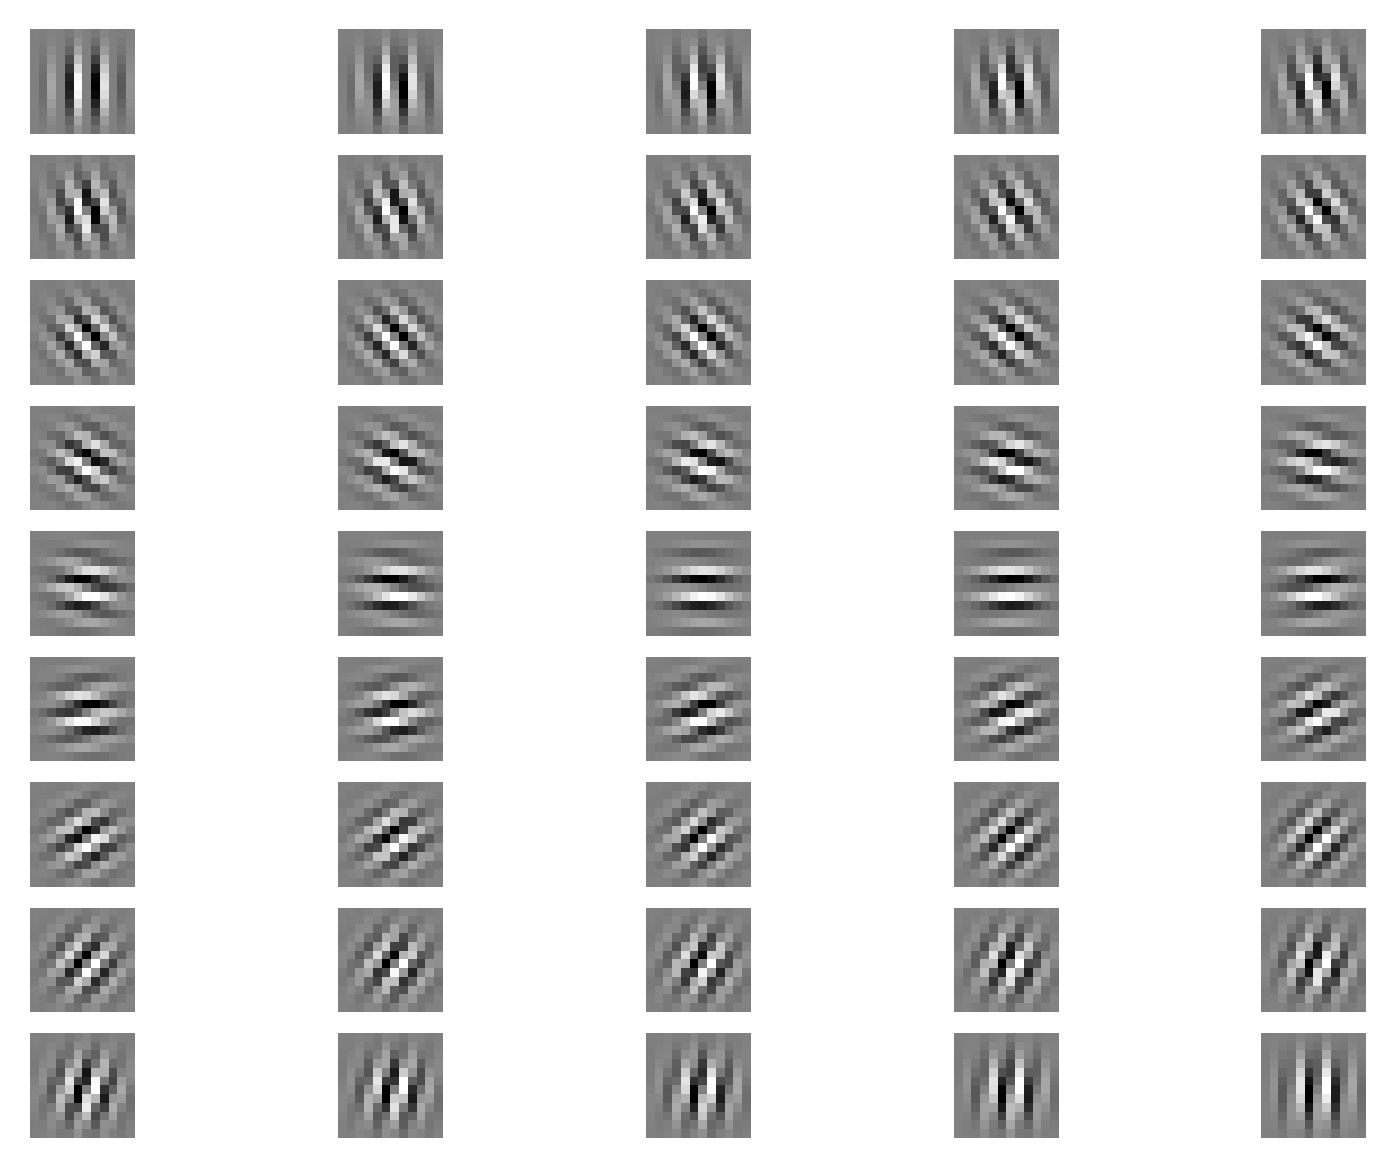

In [9]:
fig, axs = plt.subplots(9, 5, dpi=300)
for i, ax in enumerate(axs.flatten()):
    ax.imshow(stimuli[i].numpy(), cmap="gray")
    ax.axis("off")

In [10]:
import numpy as np
from task_transfer.utils.math_utils import cos2_von_mises

def plot_predictive_means_and_task_prior(
    means,
    task_params = {
        "orientations": torch.linspace(0, np.pi, steps=45 + 1)[:-1],
        "c1_psi" : np.pi / 4,
        "c2_psi" : 3 * np.pi / 4,
    },
    plotting_params = {
        "dpi": 300,
        "bar_color": "olivedrab",
        "bar_edgecolor": "black",
        "fontsize": 16,
        "linewidth": 4,
        "tick_length": 6,
        "tick_width": 2,
        "save_path": "/tmp.pdf",
        "label": "Avg firing rate $x_i$",
        "legend": False,
        "legend_loc": "upper right",
        "legend_fontsize": 16,
    }
):
    all_orientations = torch.linspace(0, torch.pi, steps=1000)
    c1_orientation_density = cos2_von_mises(all_orientations, task_params["c1_psi"], 1.0)
    c2_orientation_density = cos2_von_mises(all_orientations, task_params["c2_psi"], 1.0)
    prior = 0.5 * c1_orientation_density + 0.5 * c2_orientation_density
    fig, ax = plt.subplots(dpi=plotting_params['dpi'])
    xticks = np.array([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
    ax.set_xticks(xticks)
    ax.set_xticklabels(f"{int(xtick)}$^\circ$" for xtick in xticks * 180 / np.pi)
    ax.set_xlabel("Orientation preference $\\psi^x$ ($^\circ$)", fontsize=plotting_params["fontsize"])
    ax.bar(
        orientations,
        means,
        width=np.pi / len(orientations),
        color=plotting_params["bar_color"],
        edgecolor=plotting_params["bar_edgecolor"],
        label=plotting_params["label"],
    )
    ax.plot(
        all_orientations,
        prior,
        color="orange",
        linestyle="--",
        label="Prior $\\theta$",
        linewidth=plotting_params["linewidth"],
    )
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=plotting_params["fontsize"],
        length=plotting_params["tick_length"],
        width=plotting_params["tick_width"],
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Avg firing rate", fontsize=plotting_params["fontsize"])
    sns.despine(ax=ax, trim=True)
    ax.spines[["left", "bottom"]].set_visible(True)
    ax.spines[["left", "bottom"]].set_linewidth(plotting_params["tick_width"])
    if plotting_params["legend"]:
        ax.legend(loc=plotting_params["legend_loc"], fontsize=plotting_params["legend_fontsize"])
    fig.savefig(plotting_params["save_path"], bbox_inches="tight")
    plt.close(fig)

In [11]:
plotting_params = {
    "dpi": 300,
    "bar_color": "olivedrab",
    "bar_edgecolor": "black",
    "fontsize": 16,
    "linewidth": 4,
    "tick_length": 6,
    "tick_width": 2,
    "save_path": "/tmp.pdf",
    "label": "Avg firing rate $x_i$",
    "legend": False,
    "legend_loc": "upper right",
    "legend_fontsize": 16,
}

si_plotting_params = plotting_params.copy() 
si_plotting_params.update({"bar_color": "olivedrab"})
sbv_plotting_params = plotting_params.copy()
sbv_plotting_params.update({"bar_color": "teal"})

task_params = dict(
    orientations = torch.linspace(0, np.pi, steps=45 + 1)[:-1],
    c1_psi = np.pi / 4,
    c2_psi = 3 * np.pi / 4,
)

with torch.no_grad():
    best_si_model.eval()
    best_sbv_model.eval()
    for stimulus, orientation in zip(stimuli, task_params["orientations"]):
        stimulus = stimulus.flatten()
        si_dist = best_si_model.trainable_distribution.distribution(cond=stimulus)
        si_mean = si_dist.base_dist.concentration / si_dist.base_dist.rate
        si_plotting_params.update(
            {
                "save_path": f"/src/project/figures/learning/predictive/si/{int(np.rad2deg(orientation))}.pdf"
            }
        )
        plot_predictive_means_and_task_prior(
            si_mean, 
            task_params, 
            si_plotting_params
        )
        sbv_dist = best_sbv_model.trainable_distribution.distribution(cond=stimulus)
        sbv_mean = sbv_dist.base_dist.mean
        sbv_plotting_params.update(
            {
                "save_path": f"/src/project/figures/learning/predictive/sbv/{int(np.rad2deg(orientation))}.pdf"
            }
        )
        plot_predictive_means_and_task_prior(
            sbv_mean, 
            task_params, 
            sbv_plotting_params
        )
        # break

teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal
teal


In [12]:
si_mean

tensor([0.4807, 0.3226, 0.1805, 0.2165, 0.2681, 0.2021, 0.2991, 0.2612, 0.2895,
        0.2065, 0.1876, 0.1862, 0.2136, 0.2651, 0.2629, 0.3106, 0.2493, 0.1960,
        0.2103, 0.2209, 0.2438, 0.3010, 0.2382, 0.2071, 0.2254, 0.2820, 0.3755,
        0.2837, 0.2248, 0.2110, 0.2137, 0.2137, 0.2488, 0.2539, 0.3195, 0.2075,
        0.1800, 0.1825, 0.2250, 0.2302, 0.3240, 0.2540, 0.2250, 0.3360, 0.6986])

In [13]:
orientations.shape

torch.Size([45])

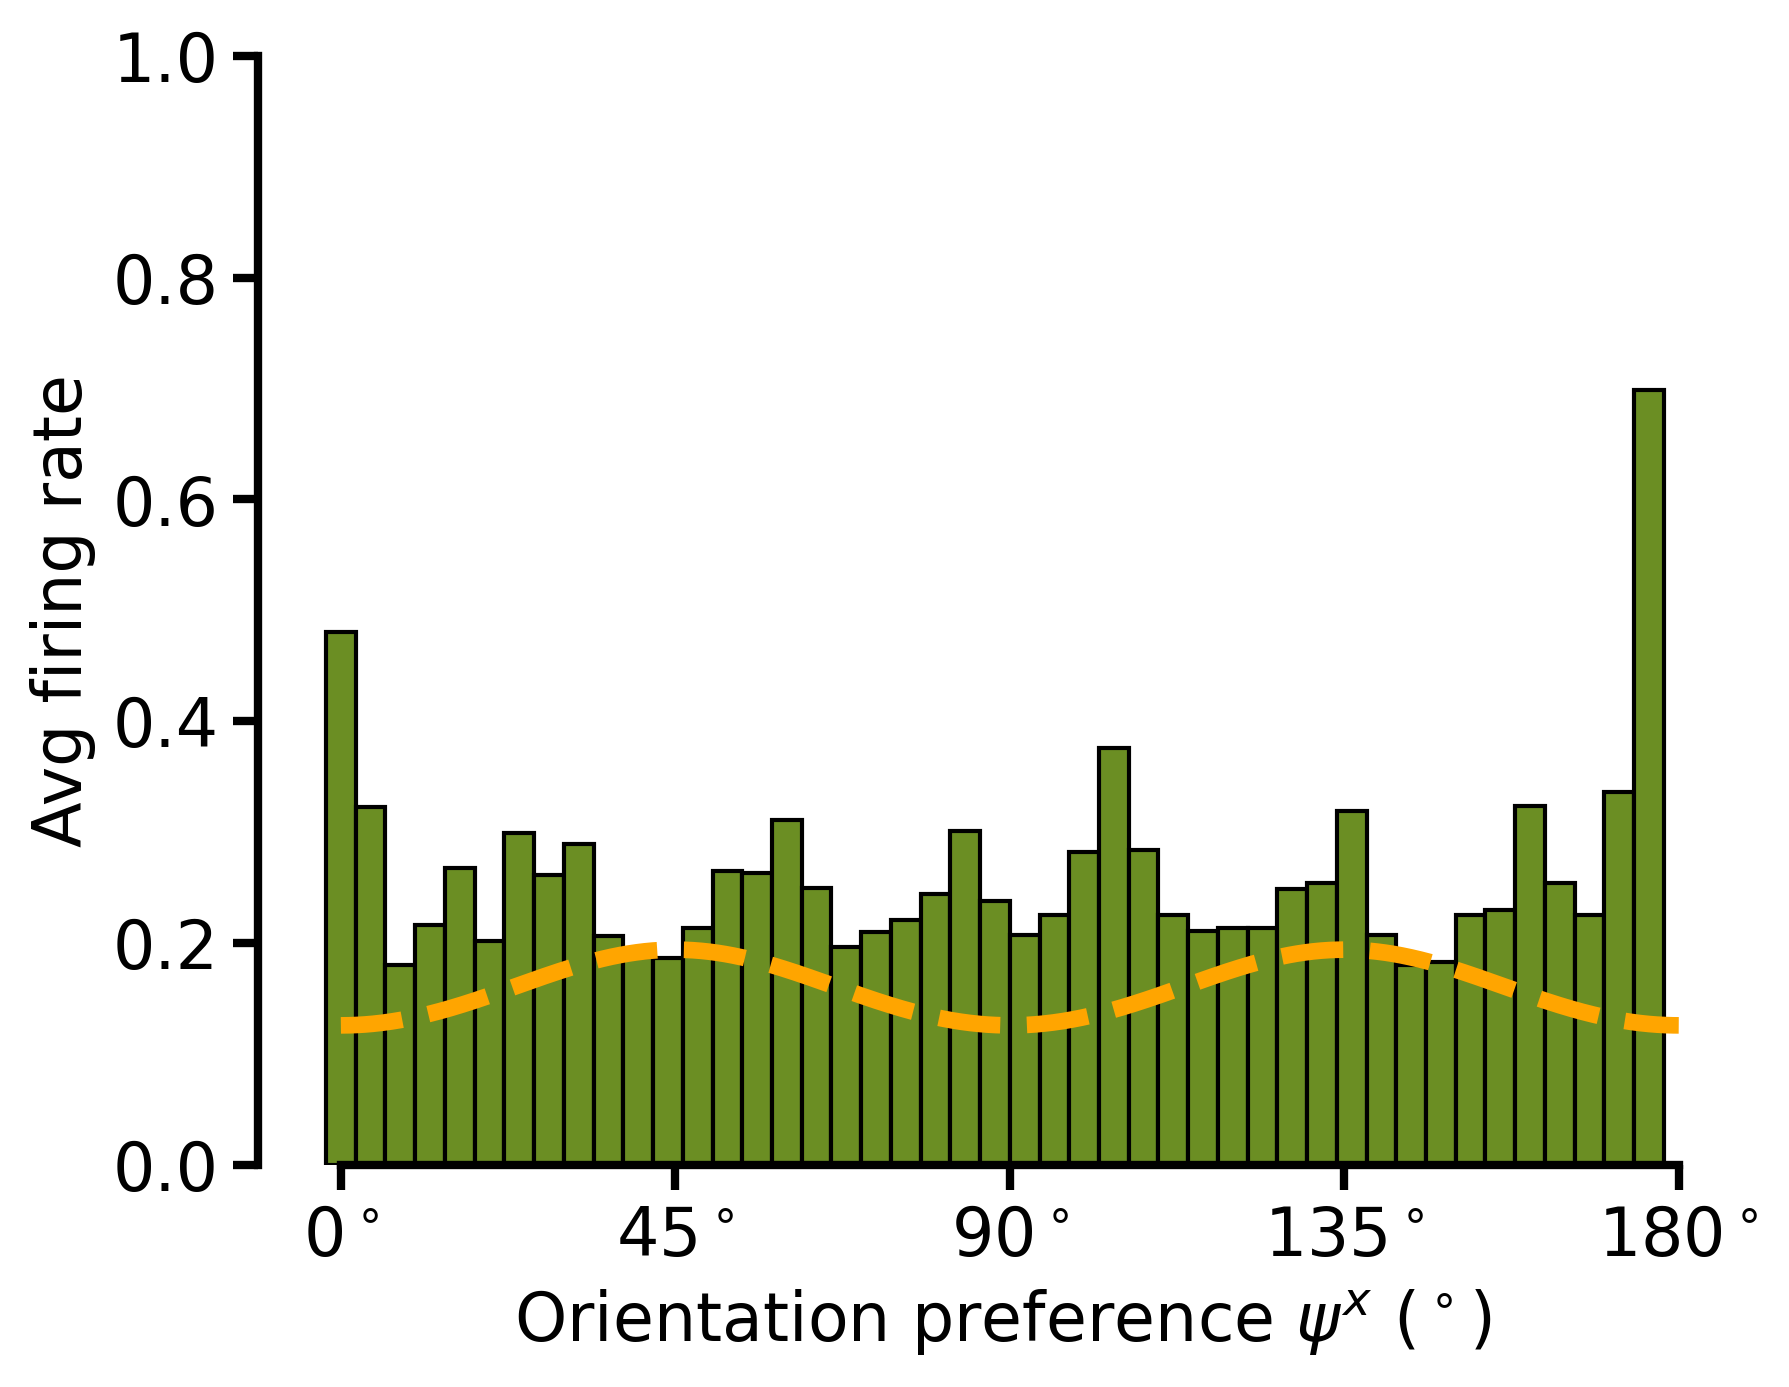

In [14]:
import numpy as np
from task_transfer.utils.math_utils import cos2_von_mises

dpi = 300
fontsize = 16
linewidth = 4
tick_length = 6
tick_width = 2

c1_psi = np.pi/4
c2_psi = 3 * np.pi/4

all_orientations = torch.linspace(0, torch.pi, steps=1000)
c1_orientation_density = cos2_von_mises(all_orientations, c1_psi, 1.0)
c2_orientation_density = cos2_von_mises(all_orientations, c2_psi, 1.0)

prior = (c1_orientation_density + c2_orientation_density)/2

fig, ax = plt.subplots(dpi=dpi)

xticks = np.array([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax.set_xticks(xticks)
ax.set_xticklabels(
    f"{int(xtick)}$^\circ$" for xtick in xticks * 180 / np.pi
)
ax.set_xlabel(
    "Orientation preference $\\psi^x$ ($^\circ$)", fontsize=fontsize
)
ax.bar(
    orientations,
    si_mean,
    width=np.pi / len(orientations),
    color="olivedrab",
    edgecolor="black",
    # alpha=0.5,
    label="Avg firing rate $x_i$",
    # zorder=0,
    # alpha=0,
)
ax.plot(
    all_orientations,
    prior,
    color="orange",
    linestyle="--",
    label="Prior $\\theta$",
    linewidth=linewidth,
)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=fontsize,
    length=tick_length,
    width=tick_width,
)
ax.set_ylim(0, 1)
ax.set_ylabel("Avg firing rate", fontsize=fontsize)
# ax.legend(fontsize=fontsize)
sns.despine(ax=ax, trim=True)
ax.spines[["left", "bottom"]].set_visible(True)
ax.spines[["left", "bottom"]].set_linewidth(tick_width)

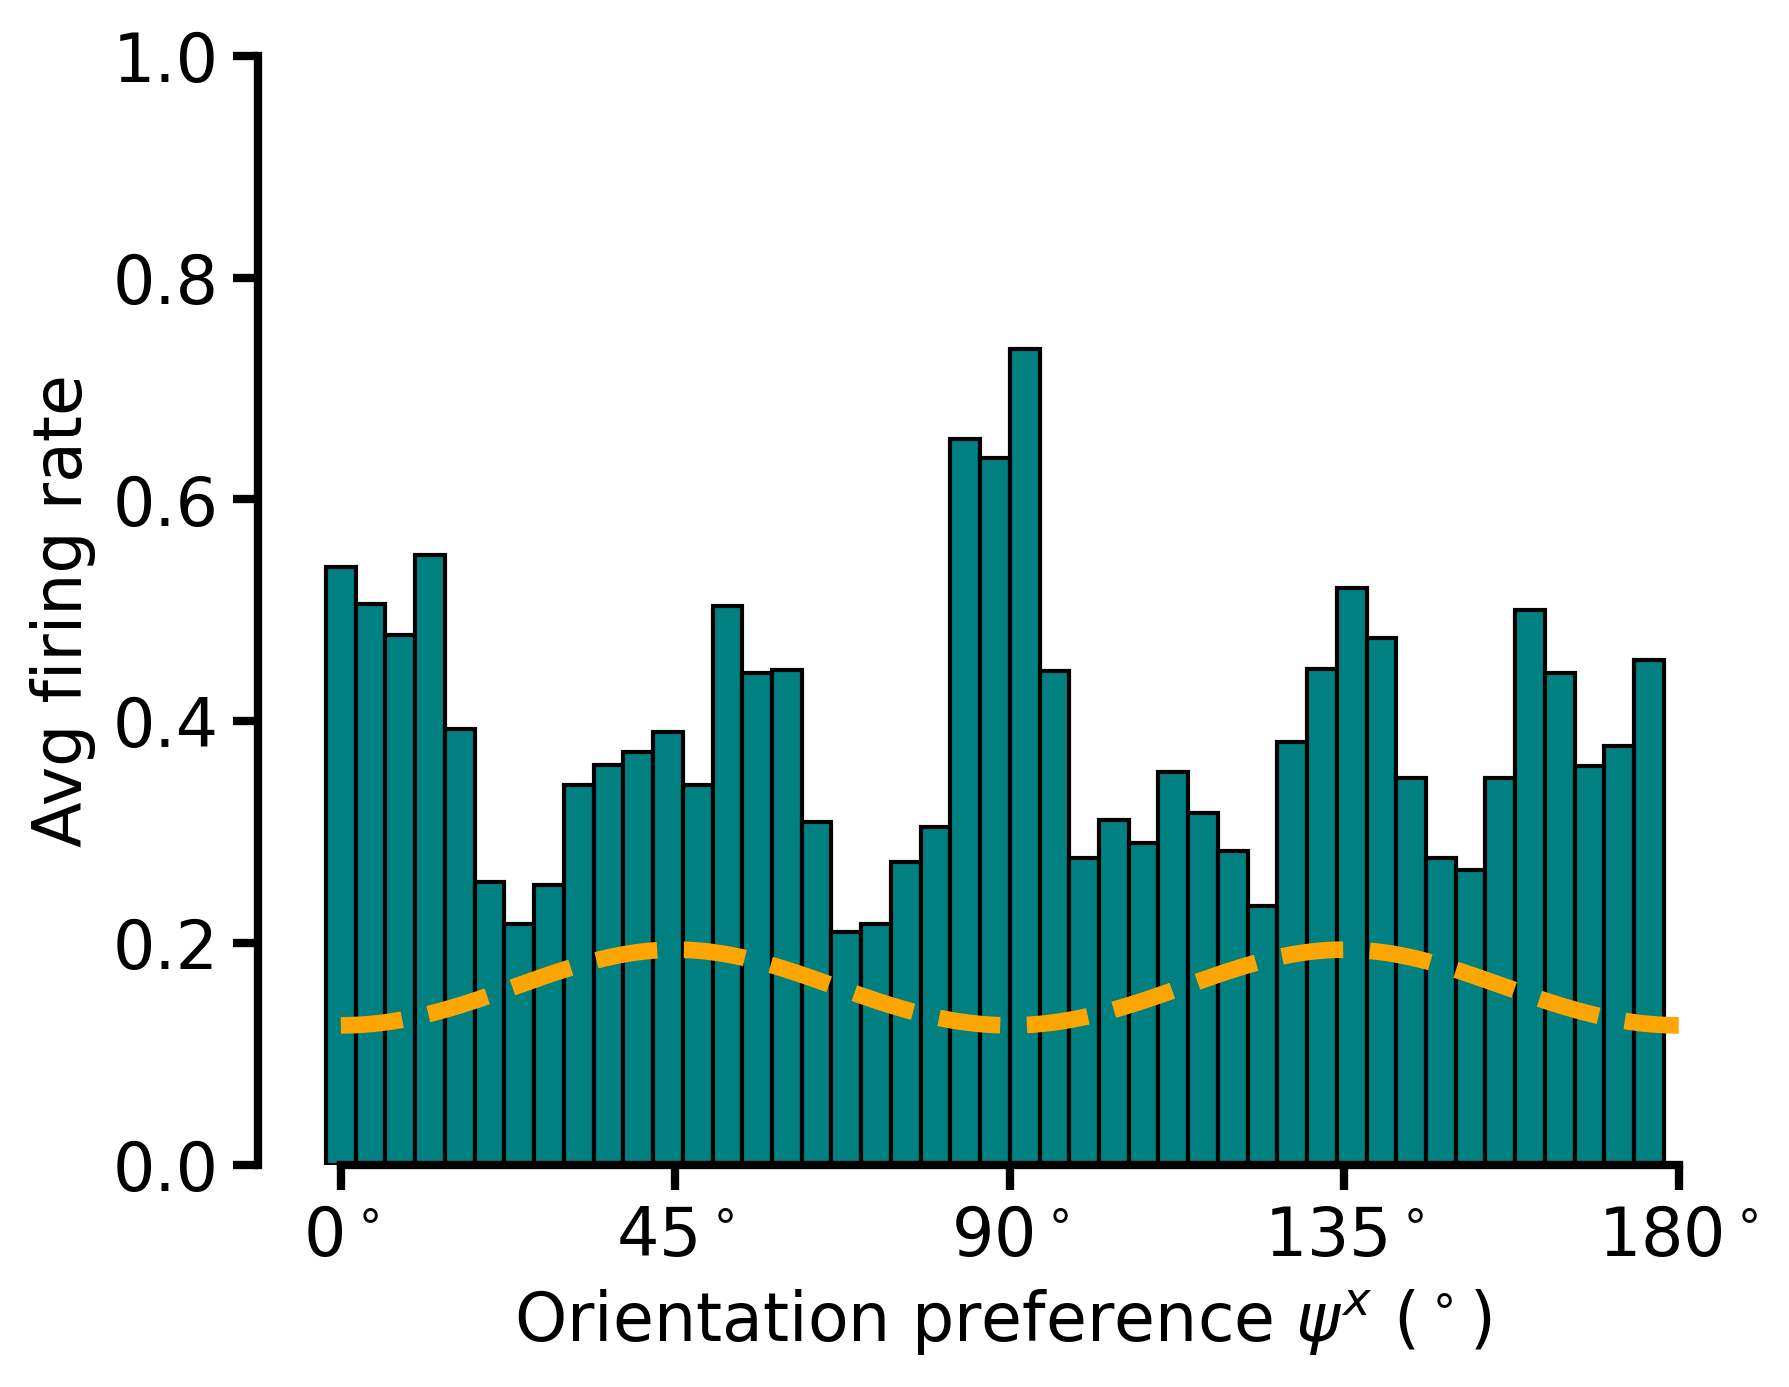

In [15]:
fig, ax = plt.subplots(dpi=dpi)

xticks = np.array([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax.set_xticks(xticks)
ax.set_xticklabels(f"{int(xtick)}$^\circ$" for xtick in xticks * 180 / np.pi)
ax.set_xlabel("Orientation preference $\\psi^x$ ($^\circ$)", fontsize=fontsize)
ax.bar(
    orientations,
    sbv_mean,
    width=np.pi / len(orientations),
    color="teal",
    edgecolor="black",
    # alpha=0.5,
    label="Avg firing rate $x_i$",
    # zorder=0,
    # alpha=0,
)
ax.plot(
    all_orientations,
    prior,
    color="orange",
    linestyle="--",
    label="Prior $\\theta$",
    linewidth=linewidth,
)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=fontsize,
    length=tick_length,
    width=tick_width,
)
# ax.legend(fontsize=fontsize)
ax.set_ylabel("Avg firing rate", fontsize=fontsize)
ax.set_ylim(0, 1)
sns.despine(ax=ax, trim=True)
ax.spines[["left", "bottom"]].set_visible(True)
ax.spines[["left", "bottom"]].set_linewidth(tick_width)